Dataset = https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting

In [103]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette('coolwarm')
%matplotlib inline

In [104]:
df = pd.read_csv(rcustomer-churn-dashboar)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [106]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Column-wise data cleaning

In [107]:
df.dropna(inplace=True)

In [108]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

We don't need this index column

In [109]:
df.drop('Row ID', inplace=True,axis=1)

Looks clean to me, there are no null values. Only two code, unfortunately there is no metadata, so no way to know what it mean. The data also doesn't shed much light on it either. 

In [110]:
df["Order ID"].str.extract(r'([A-Za-z]+)')[0].unique()

<StringArray>
['CA', 'US']
Length: 2, dtype: str

In [111]:
df.head(4)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775


Coverting columns 'Order Date' and 'Ship Date' to datetime dtypes.

In [112]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)
df[['Order Date', 'Ship Date']][0:5]

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


No null values or any discrepencies. So we move on.

In [113]:
df['Ship Mode'].unique()

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

In [114]:
df['Customer ID'].str.extract(r'([A-Za-z]+)')[0].unique()

<StringArray>
['CG', 'DV', 'SO', 'BH', 'AA', 'IM', 'HP', 'PK', 'AG', 'ZD',
 ...
 'DD', 'EK', 'GR', 'VS', 'NR', 'KS', 'AO', 'FW', 'HE', 'HD']
Length: 292, dtype: str

In [115]:
df['Customer Name'].nunique()

793

In [116]:
df['Segment'].unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

### Feature Engineering

In [117]:
df['processing_time'] = (df['Ship Date'] - df['Order Date']).dt.days

### EDA

In [118]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5849
Second Class      1901
First Class       1501
Same Day           538
Name: count, dtype: int64

In [119]:
df.groupby('Segment').count()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,processing_time
Segment,,,,,,,,,,,,,,,,,
Consumer,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096,5096
Corporate,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948,2948
Home Office,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745,1745


In [120]:
cus_seg = df['Segment'].value_counts().reset_index()
cus_seg = cus_seg.rename(columns={'Segment': 'Customer Type', 'count': 'Total Customers'})
cus_seg

,Customer Type,Total Customers
0,Consumer,5096
1,Corporate,2948
2,Home Office,1745


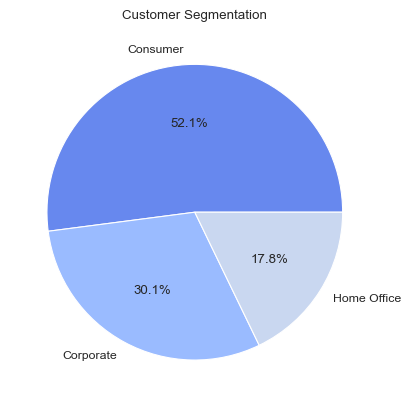

In [121]:
plt.pie(cus_seg['Total Customers'], labels=cus_seg['Customer Type'], autopct="%1.1f%%")
plt.title("Customer Segmentation")
plt.show()

In [122]:
sales_per_segment = df.groupby('Segment')['Sales'].sum().reset_index()
sales_per_segment = sales_per_segment.rename(columns={'Segment': 'Customer Type', 'Sales': 'Total Sales'})
sales_per_segment

,Customer Type,Total Sales
0,Consumer,1.146708e+06
1,Corporate,6.822118e+05
2,Home Office,4.236874e+05


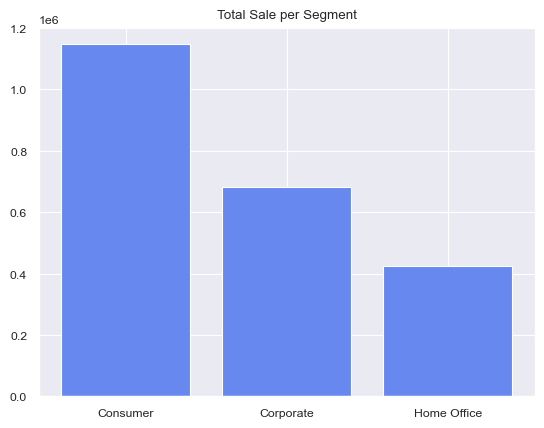

In [123]:
plt.bar(sales_per_segment['Customer Type'], sales_per_segment['Total Sales'])
plt.title('Total Sale per Segment')
plt.show()

In [124]:
customer_order_freq = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Order ID'].count().reset_index()
customer_order_freq = customer_order_freq.rename(columns={'Order ID' : 'Total Orders'})

repeat_customers = customer_order_freq[customer_order_freq['Total Orders'] >= 1]

repeat_customers.sort_values(by='Total Orders', ascending=False).head()

,Customer ID,Customer Name,Segment,Total Orders
787,WB-21850,William Brown,Consumer,35
482,MA-17560,Matt Abelman,Home Office,34
606,PP-18955,Paul Prost,Home Office,34
387,JL-15835,John Lee,Consumer,33
720,SV-20365,Seth Vernon,Consumer,32


In [125]:
highest_customer_sale = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Sales'].sum().reset_index()
highest_customer_sale.rename(columns={'Sales': 'Total Sales'}, inplace=True)

highest_customer_sale.sort_values(by='Total Sales', ascending=False).head()

,Customer ID,Customer Name,Segment,Total Sales
700,SM-20320,Sean Miller,Home Office,25043.050
741,TC-20980,Tamara Chand,Corporate,19052.218
621,RB-19360,Raymond Buch,Consumer,15117.339
730,TA-21385,Tom Ashbrook,Home Office,14595.620
6,AB-10105,Adrian Barton,Consumer,14473.571


In [126]:
mode_of_shipping = df['Ship Mode'].value_counts().reset_index()
mode_of_shipping.rename(columns={'count': 'Frequency'},inplace=True)

mode_of_shipping

,Ship Mode,Frequency
0,Standard Class,5849
1,Second Class,1901
2,First Class,1501
3,Same Day,538


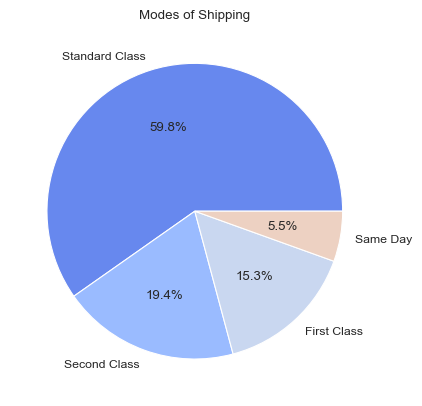

In [127]:
plt.pie( mode_of_shipping['Frequency'],labels=mode_of_shipping['Ship Mode'], autopct="%1.1f%%")

plt.title('Modes of Shipping')
plt.show()

In [128]:
total_customers_by_state = df['State'].value_counts().reset_index()
total_customers_by_state.rename(columns={'count': 'Total Customers'}, inplace=True)

total_customers_by_state.head(5)

,State,Total Customers
0,California,1946
1,New York,1097
2,Texas,973
3,Pennsylvania,582
4,Washington,504


In [129]:
sale_by_state = df.groupby('State')['Sales'].sum().reset_index()
sale_by_state.rename(columns={'Sales': 'Total Sales'},inplace=True)
sale_by_state.sort_values(by='Total Sales',ascending=False).head(5)

,State,Total Sales
3,California,446306.4635
30,New York,306361.1470
41,Texas,168572.5322
44,Washington,135206.8500
36,Pennsylvania,116276.6500


In [130]:
product_category = df['Category'].value_counts().reset_index().rename(columns={'count':'Total Count'})
product_category

,Category,Total Count
0,Office Supplies,5903
1,Furniture,2076
2,Technology,1810


In [131]:
product_subcategory = df.groupby('Category')['Sub-Category'].nunique().reset_index()
product_subcategory.rename(columns={'Category':'Sub-Category','Sub-Category': 'Total Count'}, inplace=True)
product_subcategory.sort_values(by='Total Count', ascending=False).reset_index(drop=True)

,Sub-Category,Total Count
0,Office Supplies,9
1,Furniture,4
2,Technology,4


In [132]:
sales_per_category = df.groupby('Category')['Sales'].sum().reset_index()
sales_per_category.rename(columns={'Sales':'Total Sales'}, inplace=True)
sales_per_category.sort_values(by='Total Sales', ascending=False).reset_index(drop=True)

,Category,Total Sales
0,Technology,825856.1130
1,Furniture,723538.4757
2,Office Supplies,703212.8240


In [133]:
sales_per_subcategory = df.groupby('Sub-Category')['Sales'].sum().reset_index()
sales_per_subcategory.rename(columns={'Sales':'Total Sales'}, inplace=True)
sales_per_subcategory = sales_per_subcategory.sort_values(by='Total Sales', ascending=True).reset_index(drop=True)

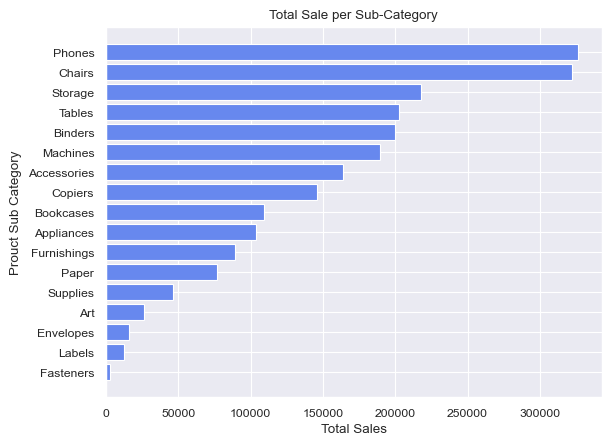

In [134]:
plt.barh(sales_per_subcategory['Sub-Category'], sales_per_subcategory['Total Sales'])
plt.xlabel('Total Sales')
plt.ylabel('Prouct Sub Category')
plt.title('Total Sale per Sub-Category')
plt.show()

In [135]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum().reset_index()
yearly_sales.rename(columns={'Order Date': 'Year', 'Sales': 'Total Sales'}, inplace=True)
yearly_sales

,Year,Total Sales
0,2015,479856.2081
1,2016,454315.9054
2,2017,597225.4900
3,2018,721209.8092


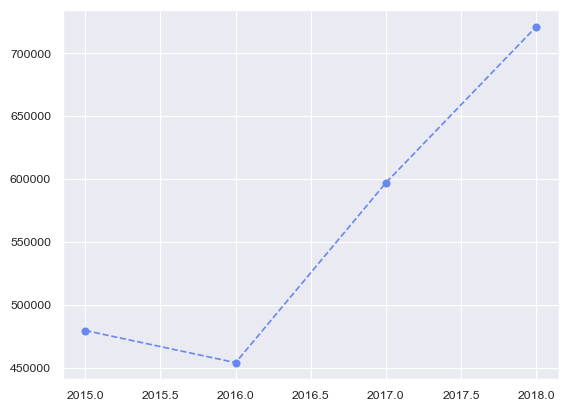

In [136]:
plt.plot(yearly_sales['Year'], yearly_sales['Total Sales'], marker='o',linestyle='--')
plt.show()

In [137]:
quartely_sales = df[df['Order Date'].dt.year == 2018]
quartely_sales = quartely_sales.resample('QE', on = 'Order Date')['Sales'].sum().reset_index()
quartely_sales.rename(columns={'Order Date': 'Yearly Quarters', 'Sales': 'Total Sales'},inplace=True)
quartely_sales.sort_values(by='Total Sales', ascending=False).reset_index(drop=True)

,Yearly Quarters,Total Sales
0,2018-12-31,278211.6450
1,2018-09-30,193815.8400
2,2018-06-30,127558.6200
3,2018-03-31,121623.7042


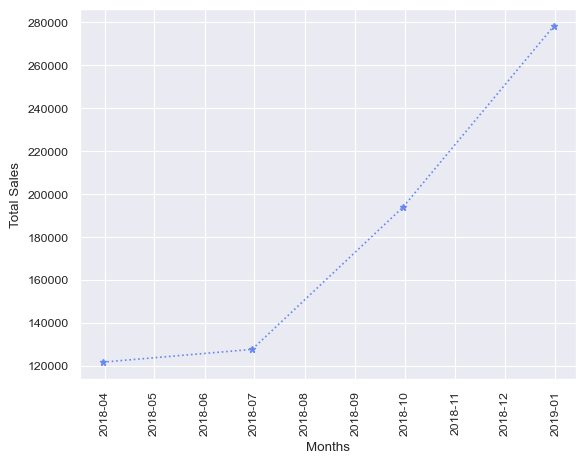

In [138]:
plt.plot(quartely_sales['Yearly Quarters'], quartely_sales['Total Sales'], marker='*',linestyle='dotted')
plt.xticks(rotation=90)
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.show()